## **Data Preparation and Pre-processing with Augmentation**

In this notebook, we will:
- Load and combine the matches and pubmed datasets.
- Perform image pre-processing and augmentation.
- Visualize some examples of the augmented images.
- Save the pre-processed images for embedding generation.

---

## **Table of Contents**
---
1. Import Libraries
2. Define Directories and Load Data
3. Combine Datasets
4. Define Image Pre-processing and Augmentation Functions
5. Apply Augmentation and Save Pre-processed Images
6. Visualize Augmented Images
7. Save Augmented Image Mapping
8. Clear Memory
9. Conclusion

---
### **Step 1: Import Libraries**

We begin by importing the necessary libraries.

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from tqdm import tqdm
import random
import gc

---
### **Step 2: Define Directories and Load Data**

We set up the directories for the datasets and load the image file names.

In [2]:
# Define directories
matches_dir = './matches/'
pubmed_dir = './pubmed_set/images'

# Combined dataset directory
combined_dir = './combined_dataset/'
os.makedirs(combined_dir, exist_ok=True)

# Get list of image files
matches_files = [f for f in os.listdir(matches_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
pubmed_files = [f for f in os.listdir(pubmed_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Number of images in matches dataset: {len(matches_files)}")
print(f"Number of images in pubmed dataset: {len(pubmed_files)}")

Number of images in matches dataset: 51
Number of images in pubmed dataset: 3309


---
### **Step 3: Combine Datasets**

We combine the two datasets into one directory.

In [3]:
# Copy images from matches dataset
for file_name in matches_files:
    src = os.path.join(matches_dir, file_name)
    dst = os.path.join(combined_dir, file_name)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

# Copy images from pubmed dataset
for file_name in pubmed_files:
    src = os.path.join(pubmed_dir, file_name)
    dst = os.path.join(combined_dir, file_name)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

# Get combined list of image files
combined_files = [f for f in os.listdir(combined_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total number of images in combined dataset: {len(combined_files)}")

Total number of images in combined dataset: 3360


---
### **Step 4: Define Helper Functions**

We define functions to perform image pre-processing and augmentation.

In [4]:
# Set random seed for reproducibility
random.seed(42)

# Define image size expected by models (e.g., 224x224)
image_size = 224

# Define data augmentation transformations
augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=image_size, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
])

# Define pre-processing transformations
preprocess = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

# Function to perform augmentation and pre-processing
def augment_and_preprocess(image_path, num_augmentations=3):
    img = Image.open(image_path).convert('RGB')
    augmented_images = []
    for _ in range(num_augmentations):
        augmented_img = augmentations(img)
        processed_img = preprocess(augmented_img)
        augmented_images.append(processed_img)
    return augmented_images

---
### **Step 5: Apply Augmentation and Save Pre-processed Images**

We apply the augmentation transformations to each image and save the augmented images.

In [5]:
# Directory to save augmented images
augmented_dir = './augmented_dataset/'
os.makedirs(augmented_dir, exist_ok=True)

# Keep track of original to augmented image mapping
augmented_mapping = []

# Process images
for image_file in tqdm(combined_files, desc='Processing Images'):
    image_path = os.path.join(combined_dir, image_file)
    # Apply augmentations
    augmented_images = augment_and_preprocess(image_path)
    # Save augmented images
    for idx, img_tensor in enumerate(augmented_images):
        augmented_filename = f"{os.path.splitext(image_file)[0]}_aug_{idx}.png"
        augmented_image_path = os.path.join(augmented_dir, augmented_filename)
        # Convert tensor to PIL Image for saving
        img = transforms.ToPILImage()(img_tensor)
        img.save(augmented_image_path)
        # Record mapping
        augmented_mapping.append({
            'original_image': image_file,
            'augmented_image': augmented_filename
        })
    # Clear memory
    del augmented_images
    gc.collect()

Processing Images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3360/3360 [05:14<00:00, 10.69it/s]


---
### **Step 6: Visualize Augmented Images**

Visualize Augmented Images

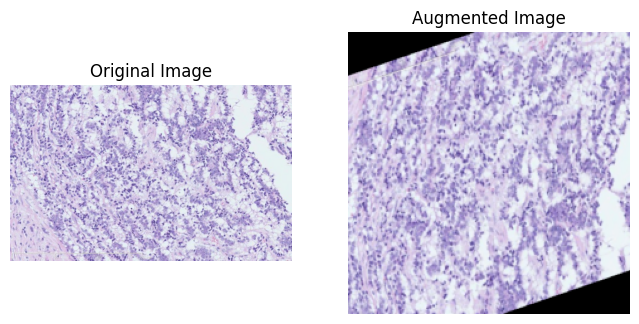

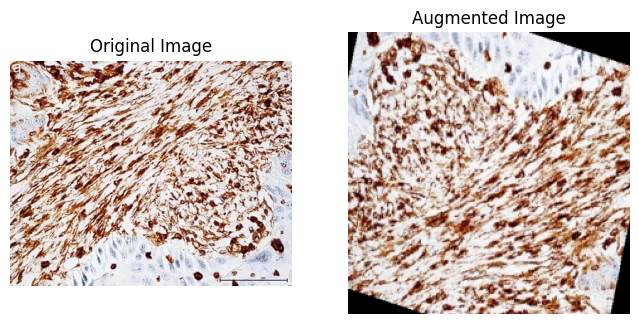

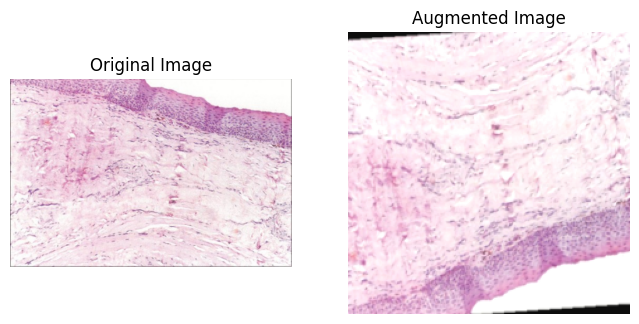

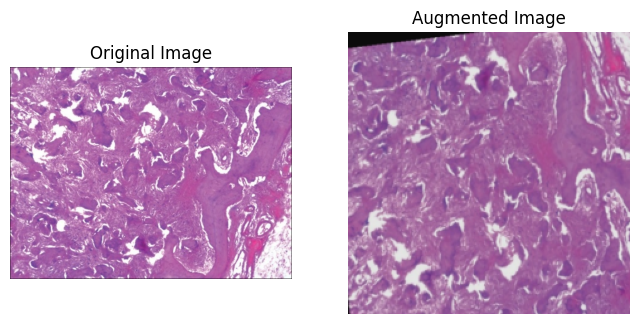

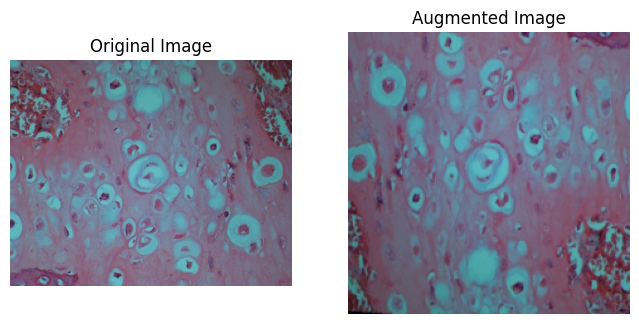

In [6]:
# Select a random sample of images to display
sample_images = random.sample(augmented_mapping, 5)

# Display the original and augmented images
for sample in sample_images:
    original_image_file = sample['original_image']
    augmented_image_file = sample['augmented_image']

    original_image_path = os.path.join(combined_dir, original_image_file)
    augmented_image_path = os.path.join(augmented_dir, augmented_image_file)

    original_image = Image.open(original_image_path)
    augmented_image = Image.open(augmented_image_path)

    # Display images side by side
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(original_image)
    axs[0].set_title('Original Image')
    axs[0].axis('off')

    axs[1].imshow(augmented_image)
    axs[1].set_title('Augmented Image')
    axs[1].axis('off')

    plt.show()

    # Clear memory
    del original_image, augmented_image
    gc.collect()

---
### **Step 7: Save Augmented Image Mapping**

We save the mapping between original images and their augmented counterparts.

In [7]:
# Convert mapping to DataFrame and save
augmented_df = pd.DataFrame(augmented_mapping)
augmented_df.to_csv('augmented_image_mapping.csv', index=False)
print("Augmented image mapping saved.")

Augmented image mapping saved.


---
### **Step 8: Clear Memory**

We clear variables and free up memory.

In [8]:
# Clear variables and free memory
del matches_files, pubmed_files, combined_files, augmented_mapping, augmented_df
gc.collect()

0

## **Conclusion**

We have successfully:
- Combined the matches and pubmed datasets.
- Applied image pre-processing and augmentation techniques.
- Visualized examples of augmented images.
- Saved the pre-processed images for embedding generation.